In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import time
# from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def calc_feq_2nd_order(rho, ux, uy, lattice_model):
    w, c, theta = lattice_model.w, lattice_model.c, lattice_model.theta
    Q = lattice_model.Q
    u_sq = ux**2 + uy**2
    cu = c[:,0].reshape(Q,1,1) * ux + c[:,1].reshape(Q,1,1) * uy
    f_eq = w.reshape(Q,1,1) * rho * (1 + cu/theta + 0.5*(cu**2)/theta**2 - 0.5*u_sq/theta)
    return f_eq

def calc_macroscopic(f, lattice_model):
    """Compute rho, ux, uy from f. f shape (Q, Ny, Nx)"""
    rho_m = np.sum(f, axis=0)
    ux_m  = np.sum(f * c[:, 0].reshape(lattice_model.Q,1,1), axis=0) / rho_m
    uy_m  = np.sum(f * c[:, 1].reshape(lattice_model.Q,1,1), axis=0) / rho_m
    return rho_m, ux_m, uy_m

In [3]:
from dataclasses import dataclass

@dataclass
class LatticeModel:
    w: np.array       # weights
    c: np.array       # discrete velocities
    theta: float  # lattice speed of sound squared
    D: int                # number of dimensions
    Q: int                # number of directions

# Instantiate D2Q9 model
w = np.array([4/9] + 4*[1/9] + 4*[1/36])
c = np.array([
    # ex, ey
    [ 0,  0],  # 0, central
    [ 1,  0],  # 1, cardinal right x+
    [ 0,  1],  # 2, cardinal up y+
    [-1,  0],  # 3, cardinal left x-
    [ 0, -1],  # 4, cardinal down y-
    [ 1,  1],  # 5, diagonal right-up 
    [-1,  1],  # 6, diagonal left-up
    [-1, -1],  # 7, diagonal left-down
    [ 1, -1],  # 8, diagonal right-down
], dtype=int)
theta = 1/3
D,Q = 2,9

D2Q9 = LatticeModel(w=w, c=c, theta=theta, D=D, Q=Q)

In [4]:
# Macroscopic Physical variables
L, W = 0.01, 0.01 # lenght x width of space, in m
D = 0.01 # characteristic length, in m (e.g obstacle size)
RHO = 1e3 # fluid density in kg/m3
U_phys = 0.04 # velocity in m/s
mu_phys = 1e-3 # dynamic viscosity
nu_phys = mu_phys / RHO # kinematic viscosity
g = 9.8 # gravity m/s2
Re = U_phys * W / nu_phys
print(f'Reynolds Number: {Re:.2f}')

# space resolution
dx = 2e-5
Nx, Ny = int(np.ceil(L/dx)), int(np.ceil(W/dx))
print(f'dx: {dx} with [{Nx}, {Ny}] grids')

# velocity in lattice unit
u_lattice = 0.08
print(f'Mach Number = {u_lattice/np.sqrt(theta):.3f}')

# time resolution
dt = u_lattice * dx / U_phys
tau = 0.5 + nu_phys * dt / (theta * (dx**2))
nu_lattice = theta * (tau - 0.5)
g_lattice = g * (dt**2)/dx
print(f'delta t: {dt}s')
print(f'tau: {tau}')
print(f'nu_lattice: {nu_lattice}')

# density
rho_lattice = 1

Reynolds Number: 400.00
dx: 2e-05 with [500, 500] grids
Mach Number = 0.139
delta t: 4e-05s
tau: 0.8
nu_lattice: 0.1


In [5]:
# initiate macroscopic variable
rho = np.full((Ny, Nx), rho_lattice, dtype=float)
ux  = np.full((Ny, Nx), u_lattice, dtype=float) # fluid already moving at ux
uy  = np.full((Ny, Nx), 0, dtype=float) # no flow in y direction

# wall on top and bottom
ux[ 0, :] = 0
ux[-1, :] = 0
uy[ 0, :] = 0
uy[-1, :] = 0

# initial distribution function in equilibrium
f = calc_feq_2nd_order(rho, ux, uy, D2Q9)

# check conservation of mass
print((f.sum() - rho.sum()) / rho.sum())

-2.328306436538696e-16


In [6]:
t, t_max = 0, 2500

u_sample = []
t_sample = []
start = time.time()
while t < t_max:
    # macroscopic and next equilibrium distribution
    rho, ux, uy = calc_macroscopic(f, D2Q9)
    feq = calc_feq_2nd_order(rho, ux, uy, D2Q9)
    if t % 1000 == 0 or (t <= 1000 and t % 10 == 0):
        t_sample.append(t)
        u_sample.append(ux[:,50])
        
    # collision
    f_star = f - (1/(tau + 0.5)) * (f - feq)
    
    # streaming
    for i in range(9):
        cx, cy = c[i]
        # np.roll handles periodic boundaries by default
        f[i] = np.roll(f_star[i], shift=cx, axis=1)  # x-direction
        f[i] = np.roll(f[i], shift=cy, axis=0)       # y-direction

    # --- Bounce-back at top/bottom walls (y=0 and y=Ny-1) ---
    # Bottom wall (y=0)
    f[ [1,5,8], 0, :] = f_star[ [3,7,6], 0, :]  # x+ directions reflect to x-
    f[ [3,6,7], 0, :] = f_star[ [1,5,8], 0, :]  # x- directions reflect to x+ (optional, for completeness)
    
    # Top wall (y=Ny-1)
    f[ [1,5,8], Ny-1, :] = f_star[ [3,7,6], Ny-1, :]
    f[ [3,6,7], Ny-1, :] = f_star[ [1,5,8], Ny-1, :]
    
    t += 1
duration = (time.time() - start)
print(f'Finish in {duration:.2f}s')

Finish in 38.82s


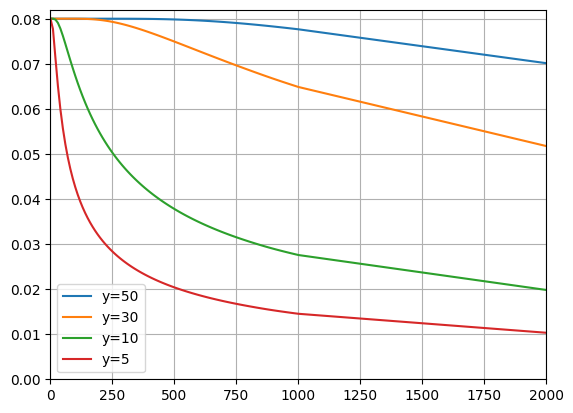

In [7]:
u_sample = np.array(u_sample)
t_sample = np.array(t_sample)
u_sample.shape

plt.plot(t_sample, u_sample[:, 50], label='y=50')
plt.plot(t_sample, u_sample[:, 30], label='y=30')
plt.plot(t_sample, u_sample[:, 10], label='y=10')
plt.plot(t_sample, u_sample[:, 5], label='y=5')
plt.legend()
plt.xlim([0,t_sample.max()])
plt.ylim([0, u_lattice * 1.025])
plt.grid()
plt.show()